In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

print("--- First 5 Rows of the Dataset ---")
display(df.head())

print("\n--- Dataset Summary ---")
df.info()

--- First 5 Rows of the Dataset ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- Dataset Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


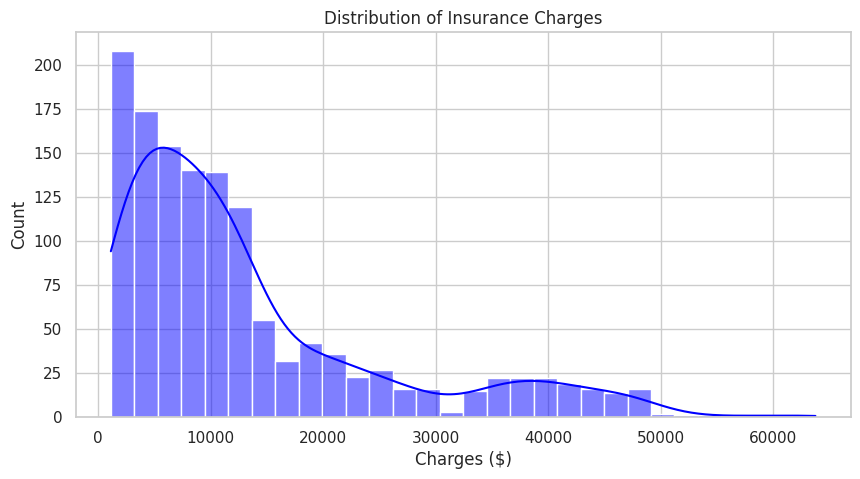

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(df['charges'], kde=True, color='blue')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Count')
plt.show()

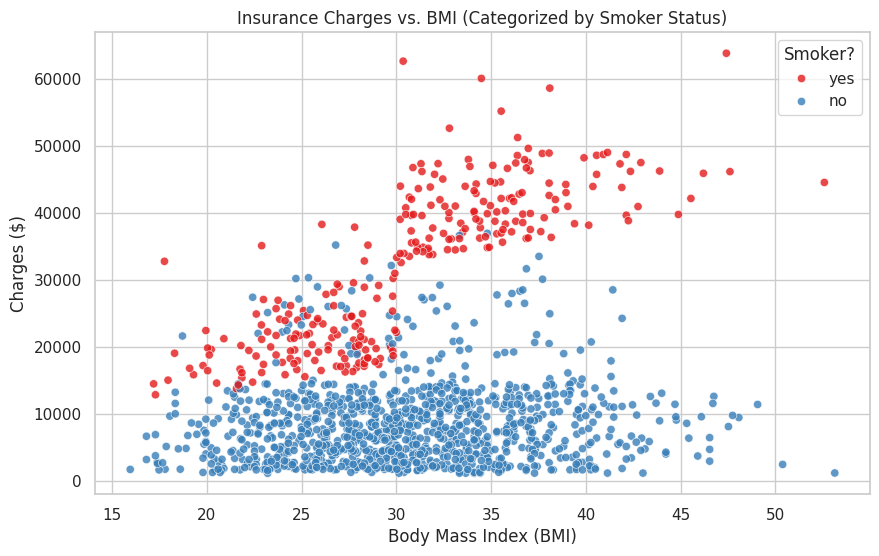

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.8)
plt.title('Insurance Charges vs. BMI (Categorized by Smoker Status)')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker?')
plt.show()

/tmp/ipykernel_950/2027886145.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='charges', ax=axes[0], palette='pastel')
/tmp/ipykernel_950/2027886145.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='charges', ax=axes[1], palette='pastel')


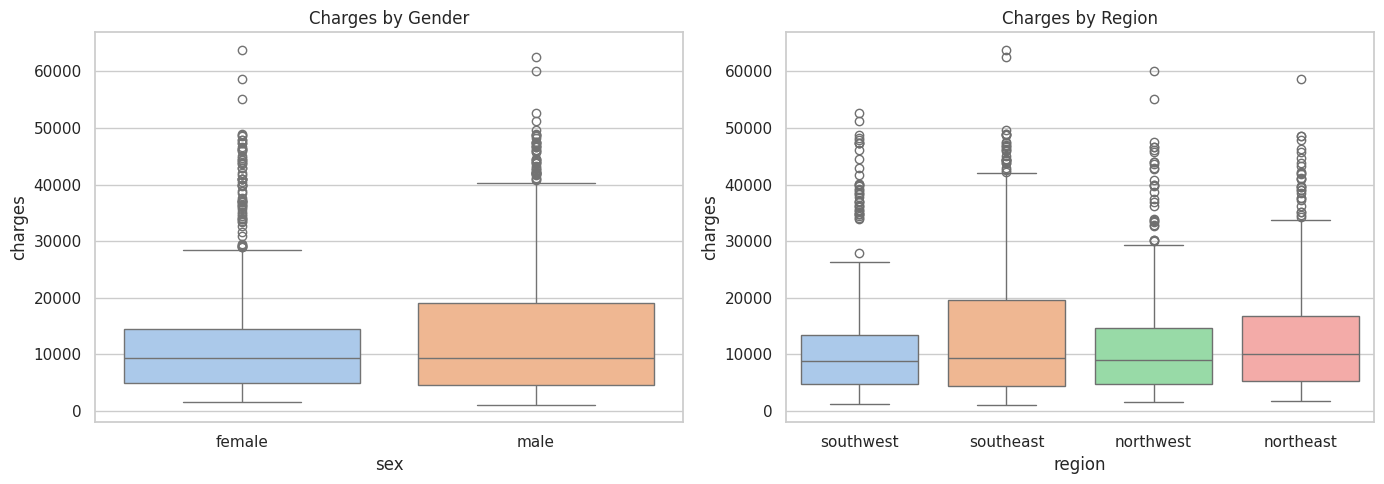

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#for Sex vs Charges
sns.boxplot(data=df, x='sex', y='charges', ax=axes[0], palette='pastel')
axes[0].set_title('Charges by Gender')

#for Region vs Charges
sns.boxplot(data=df, x='region', y='charges', ax=axes[1], palette='pastel')
axes[1].set_title('Charges by Region')

plt.tight_layout()
plt.show()

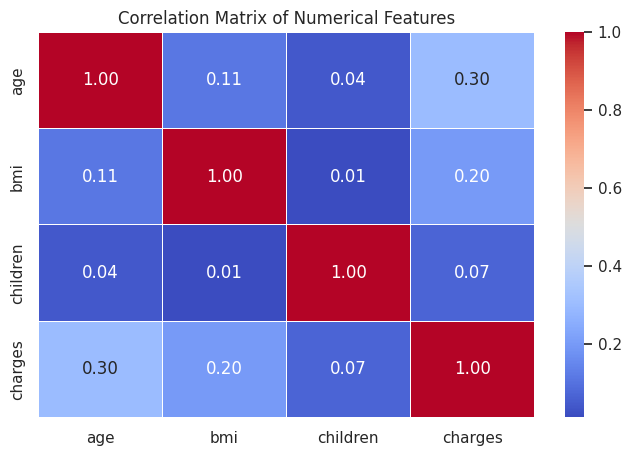

In [ ]:
plt.figure(figsize=(8, 5))
numerical_df = df[['age', 'bmi', 'children', 'charges']]
correlation_matrix = numerical_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
processed_df = df.copy()

# BMI >= 30 is clinically categorized as obese
processed_df['obese_smoker'] = ((processed_df['bmi'] >= 30) & (processed_df['smoker'] == 'yes')).astype(int)

processed_df['smoker'] = processed_df['smoker'].map({'yes': 1, 'no': 0})
processed_df['sex'] = processed_df['sex'].map({'male': 1, 'female': 0})

processed_df = pd.get_dummies(processed_df, columns=['region'], drop_first=True, dtype=int)

processed_df['log_charges'] = np.log1p(processed_df['charges'])

print("Processed Data Features ")
display(processed_df.head())

Processed Data Features 


,age,sex,bmi,children,smoker,charges,obese_smoker,region_northwest,region_southeast,region_southwest,log_charges
0,19,0,27.900,0,1,16884.92400,0,0,0,1,9.734236
1,18,1,33.770,1,0,1725.55230,0,0,1,0,7.453882
2,28,1,33.000,3,0,4449.46200,0,0,1,0,8.400763
3,33,1,22.705,0,0,21984.47061,0,1,0,0,9.998137
4,32,1,28.880,0,0,3866.85520,0,1,0,0,8.260455


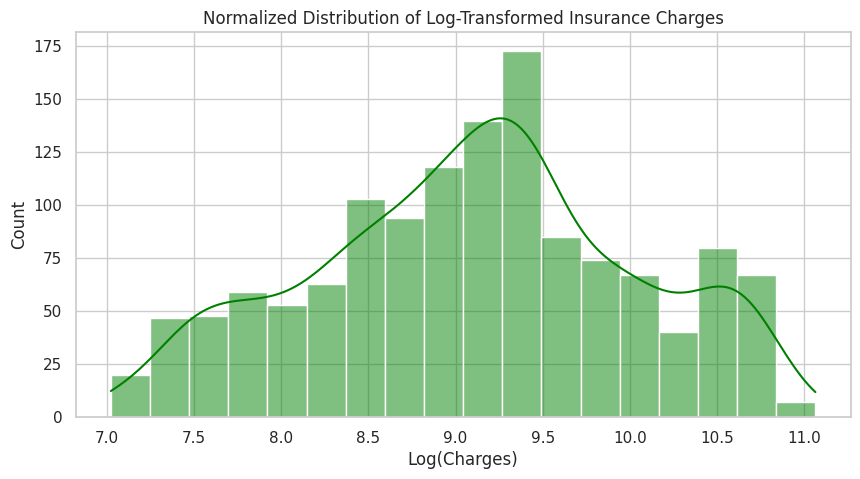

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(processed_df['log_charges'], kde=True, color='green')
plt.title('Normalized Distribution of Log-Transformed Insurance Charges')
plt.xlabel('Log(Charges)')
plt.ylabel('Count')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = processed_df.drop(columns=['charges', 'log_charges'])

y = processed_df['log_charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (1070, 9)
Testing features shape: (268, 9)


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01)
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    log_preds = model.predict(X_test)

    true_charges = np.expm1(y_test)
    pred_charges = np.expm1(log_preds)

    mae = mean_absolute_error(true_charges, pred_charges)
    rmse = np.sqrt(mean_squared_error(true_charges, pred_charges))
    r2 = r2_score(true_charges, pred_charges)

    results[name] = {'MAE ($)': round(mae, 2), 'RMSE ($)': round(rmse, 2), 'R2 Score': round(r2, 4)}

results_df = pd.DataFrame(results).T
print("--- Advanced Regression Model Comparison Matrix ---")
display(results_df)

--- Advanced Regression Model Comparison Matrix ---


,MAE ($),RMSE ($),R2 Score
Linear Regression,3699.00,7639.23,0.6241
Ridge Regression,3674.21,7573.46,0.6305
Lasso Regression,3449.31,6893.27,0.6939


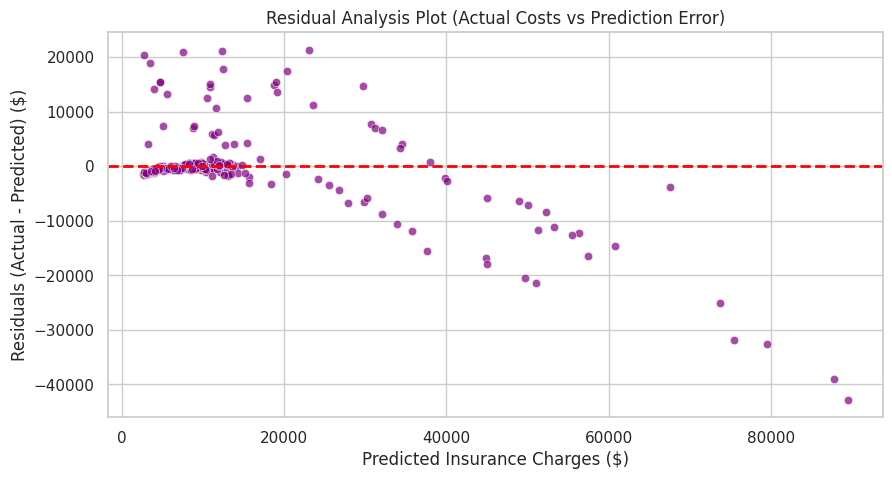

In [ ]:
best_model = models['Linear Regression']
log_preds = best_model.predict(X_test)
true_charges = np.expm1(y_test)
pred_charges = np.expm1(log_preds)

residuals = true_charges - pred_charges

plt.figure(figsize=(10, 5))
sns.scatterplot(x=pred_charges, y=residuals, alpha=0.7, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Analysis Plot (Actual Costs vs Prediction Error)')
plt.xlabel('Predicted Insurance Charges ($)')
plt.ylabel('Residuals (Actual - Predicted) ($)')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

y_raw = processed_df['charges']
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y_raw, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_raw, y_train_raw)

rf_preds = rf_model.predict(X_test_raw)

rf_mae = mean_absolute_error(y_test_raw, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test_raw, rf_preds))
rf_r2 = r2_score(y_test_raw, rf_preds)

results_df.loc['Random Forest'] = [round(rf_mae, 2), round(rf_rmse, 2), round(rf_r2, 4)]
print("--- Updated Model Comparison Matrix ---")
display(results_df)

--- Updated Model Comparison Matrix ---


,MAE ($),RMSE ($),R2 Score
Linear Regression,3699.00,7639.23,0.6241
Ridge Regression,3674.21,7573.46,0.6305
Lasso Regression,3449.31,6893.27,0.6939
Random Forest,2561.10,4648.55,0.8608


In [ ]:
import pickle

with open('health_cost_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

model_columns = list(X.columns)
with open('model_columns.pkl', 'wb') as file:
    pickle.dump(model_columns, file)

print("Model artifacts successfully serialized and saved!")

Model artifacts successfully serialized and saved!
